In [1]:
import sys, numpy as np
print(sys.executable)
print(np.__version__)

/projects/battobrah@xsede.org/software/anaconda/envs/HB3/bin/python
1.21.6


In [2]:
import sys

sys.path.append(
    "/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages"
)

from dask import delayed, compute
from dask.distributed import Client

print("Dask imported")

Dask imported


In [3]:
from dask import delayed, compute
from dask.distributed import Client

client = Client(
    n_workers=4,
    threads_per_worker=1,
    processes=True
)

print(client)

@delayed
def square(x):
    return x * x

results = compute(*[square(i) for i in range(10)])
print(results)

client.shutdown()

<Client: 'tcp://127.0.0.1:44921' processes=4 threads=4, memory=15.00 GiB>
(0, 1, 4, 9, 16, 25, 36, 49, 64, 81)


Reading from: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir
Number of daily files: 4015
First file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir/20140101.nc
Last file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir/20241228.nc
Winter 2014 files: 90
First selected: 20140101.nc
Last selected : 20141231.nc
Dimensions: dict_keys(['lon', 'lat', 't'])
Variables: dict_keys(['lon', 'lat', 't', 'trad', 'smc', 'swe', 'snowh', 'fsno'])
Longitude: -114.23375 to -103.75042
Latitude : 33.75042 to 44.23375
Processing 1/90: 20140101.nc


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1454779/2980063277.py:101: RuntimeWarning: Mean of empty slice
  daily_mean = np.nanmean(data, axis=0)


Processing 11/90: 20140111.nc
Processing 21/90: 20140121.nc
Processing 31/90: 20140131.nc
Processing 41/90: 20140210.nc
Processing 51/90: 20140220.nc
Processing 61/90: 20141202.nc
Processing 71/90: 20141212.nc
Processing 81/90: 20141222.nc


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1454779/2980063277.py:112: RuntimeWarning: invalid value encountered in true_divide
  season_mean = sum_map / count_map


Saved: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots/PP_smc_Winter_2014_seasonal_mean.png


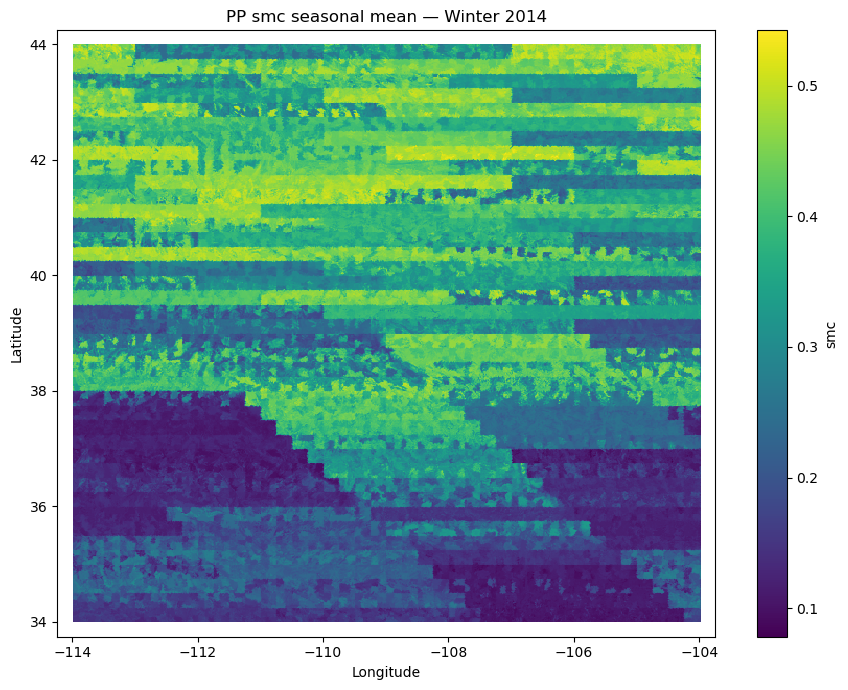

In [1]:
# ONE-YEAR TEST: one variable, one season, from postprocessed daily files

import os
import glob
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt

# SETTINGS

experiment_dir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"

post_dir = f"{experiment_dir}/postprocess/output_dir"

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

varname = "smc"          # options: "smc", "swe", "snowh", "fsno", "trad"

test_year = 2014

season_name = "Winter"
season_months = (12, 1, 2)

print("Reading from:", post_dir)

# GET DAILY FILES

files = sorted(glob.glob(f"{post_dir}/*.nc"))

print("Number of daily files:", len(files))
print("First file:", files[0])
print("Last file:", files[-1])

# SELECT ONE YEAR + ONE SEASON

season_files = []

for f in files:
    fname = os.path.basename(f).replace(".nc", "")
    date = pd.to_datetime(fname, format="%Y%m%d")

    if (date.year == test_year) and (date.month in season_months):
        season_files.append(f)

print(f"{season_name} {test_year} files:", len(season_files))

if len(season_files) == 0:
    raise RuntimeError("No files selected. Check test_year and season_months.")

print("First selected:", os.path.basename(season_files[0]))
print("Last selected :", os.path.basename(season_files[-1]))

# READ COORDINATES

fp = nc.Dataset(season_files[0])

print("Dimensions:", fp.dimensions.keys())
print("Variables:", fp.variables.keys())

lon = fp.variables["lon"][:]
lat = fp.variables["lat"][:]

fp.close()

print(f"Longitude: {lon[0]:.5f} to {lon[-1]:.5f}")
print(f"Latitude : {lat[0]:.5f} to {lat[-1]:.5f}")

# ACCUMULATE SEASONAL MEAN

sum_map = None
count_map = None

for i, f in enumerate(season_files):

    if i % 10 == 0:
        print(f"Processing {i+1}/{len(season_files)}: {os.path.basename(f)}", flush=True)

    fp = nc.Dataset(f)

    data = np.array(fp.variables[varname][:], dtype=float)

    fp.close()

    # Convert fill values to NaN
    data[data <= -9990] = np.nan

    # Average 8 three-hourly timesteps into daily mean
    with np.errstate(all="ignore"):
        daily_mean = np.nanmean(data, axis=0)

    if sum_map is None:
        sum_map = np.zeros_like(daily_mean, dtype=float)
        count_map = np.zeros_like(daily_mean, dtype=float)

    valid = np.isfinite(daily_mean)

    sum_map[valid] += daily_mean[valid]
    count_map[valid] += 1

season_mean = sum_map / count_map
season_mean = np.ma.masked_invalid(season_mean)

# PLOT

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.pcolormesh(
    lon,
    lat,
    season_mean,
    cmap="viridis",
    shading="auto"
)

ax.set_title(f"PP {varname} seasonal mean — {season_name} {test_year}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label=varname)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    f"PP_{varname}_{season_name}_{test_year}_seasonal_mean.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

dem_file = path + "postprocess/dem.vrt"

dem = gdal_tools.read_raster(dem_file).astype(float)
metad = gdal_tools.retrieve_metadata(dem_file)

dem[dem == -9999] = np.nan

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

plt.figure(figsize=(10, 8))

im = plt.pcolormesh(
    coords_x,
    coords_y,
    np.flipud(dem),
    cmap="terrain",
    shading="auto"
)

plt.colorbar(im, label="DEM [m]")
plt.title("DEM - full domain")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

outfile = os.path.join(outputdir, "static_dem_full_domain_from_vrt.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Processing CID 50
Processing CID 100
Processing CID 150
Processing CID 200
Processing CID 250
Processing CID 300
Processing CID 350
Processing CID 400
Processing CID 450
Processing CID 500
Processing CID 550
Processing CID 600
Processing CID 650
Processing CID 700
Processing CID 750
Processing CID 800
Processing CID 850
Processing CID 900


: 

: 

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/static_dem_full_domain_from_vrt.png


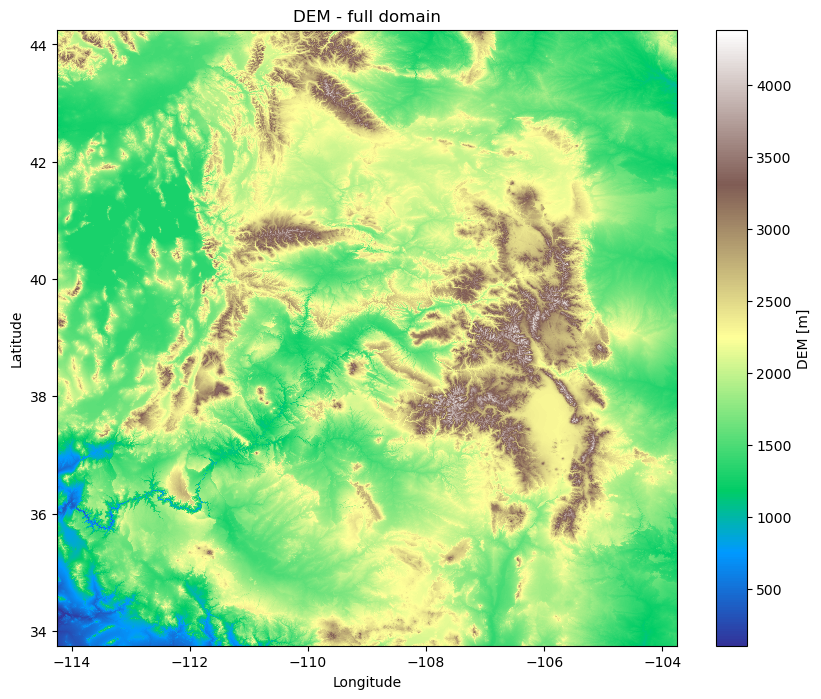

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

dem_file = path + "postprocess/dem.vrt"

dem = gdal_tools.read_raster(dem_file).astype(float)
metad = gdal_tools.retrieve_metadata(dem_file)

dem[dem == -9999] = np.nan

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

plt.figure(figsize=(10, 8))

im = plt.pcolormesh(
    coords_x,
    coords_y,
    np.flipud(dem),
    cmap="terrain",
    shading="auto"
)

plt.colorbar(im, label="DEM [m]")
plt.title("DEM - full domain")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

outfile = os.path.join(outputdir, "static_dem_full_domain_from_vrt.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

In [2]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# 
# PATHS
# 

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# 
# READ HRU AND CID MAPS
# 

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# 
# VARIABLES
# 
var2plot = ["dem", "slope","y_aspect", "x_aspect","svf", "tvf","hor_n", "hor_w"]
#var2plot = ["dem"]

cid_list = range(1, 1601)

# 
# PLOT
# 

fig, axes = plt.subplots(4, 2, figsize=(11, 15))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"\nPlotting {var}", flush=True)

    final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

    for cid in cid_list:

        if cid % 50 == 0:
            print(f"  Processing CID {cid}", flush=True)

        fp_path = path + f"{cid}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}", flush=True)
            continue

        fp = nc.Dataset(fp_path)
        grp = fp.groups["parameters"]

        if var not in grp.variables:
            print(f"{var} missing in CID {cid}", flush=True)
            fp.close()
            continue

        data = np.array(grp.variables[var][:], dtype=np.float32)
        fp.close()

        mask = (hrus != -9999) & (cids == cid)

        hru_ids = hrus[mask].astype(np.int32)
        valid = (hru_ids >= 0) & (hru_ids < len(data))

        rows, cols = np.where(mask)
        final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

    final_map[final_map == -9999.0] = np.nan

    im = ax.imshow(
        final_map,
        origin="lower",
        extent=extent,
        cmap="terrain",
        interpolation="nearest"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()

outfile = os.path.join(outputdir, "static_variables_HRU_mapped_100hru_full_domain.png")
plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/

Plotting dem
  Processing CID 50
  Processing CID 100
  Processing CID 150
  Processing CID 200
  Processing CID 250
  Processing CID 300
  Processing CID 350
  Processing CID 400
  Processing CID 450
  Processing CID 500
  Processing CID 550
  Processing CID 600
  Processing CID 650
  Processing CID 700
  Processing CID 750
  Processing CID 800
  Processing CID 850
  Processing CID 900
  Processing CID 950
  Processing CID 1000
  Processing CID 1050
  Processing CID 1100
  Processing CID 1150
  Processing CID 1200
  Processing CID 1250
  Processing CID 1300
  Processing CID 1350
  Processing CID 1400
  Processing CID 1450
  Processing CID 1500
  Processing CID 1550
  Processing CID 1600

Plotting slope
  Processing CID 50
  Processing CID 100
  Processing CID 150
  Processing CID 200
  Processing CID 250
  Processin

: 

: 

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/

Plotting dem
  Processing CID 50
  Processing CID 100
  Processing CID 150
  Processing CID 200
  Processing CID 250
  Processing CID 300
  Processing CID 350
  Processing CID 400
  Processing CID 450
  Processing CID 500
  Processing CID 550
  Processing CID 600
  Processing CID 650
  Processing CID 700
  Processing CID 750
  Processing CID 800
  Processing CID 850
  Processing CID 900
  Processing CID 950
  Processing CID 1000
  Processing CID 1050
  Processing CID 1100
  Processing CID 1150
  Processing CID 1200
  Processing CID 1250
  Processing CID 1300
  Processing CID 1350
  Processing CID 1400
  Processing CID 1450
  Processing CID 1500
  Processing CID 1550
  Processing CID 1600

Plotting slope
  Processing CID 50
  Processing CID 100
  Processing CID 150
  Processing CID 200
  Processing CID 250
  Processin

IndexError: list index out of range

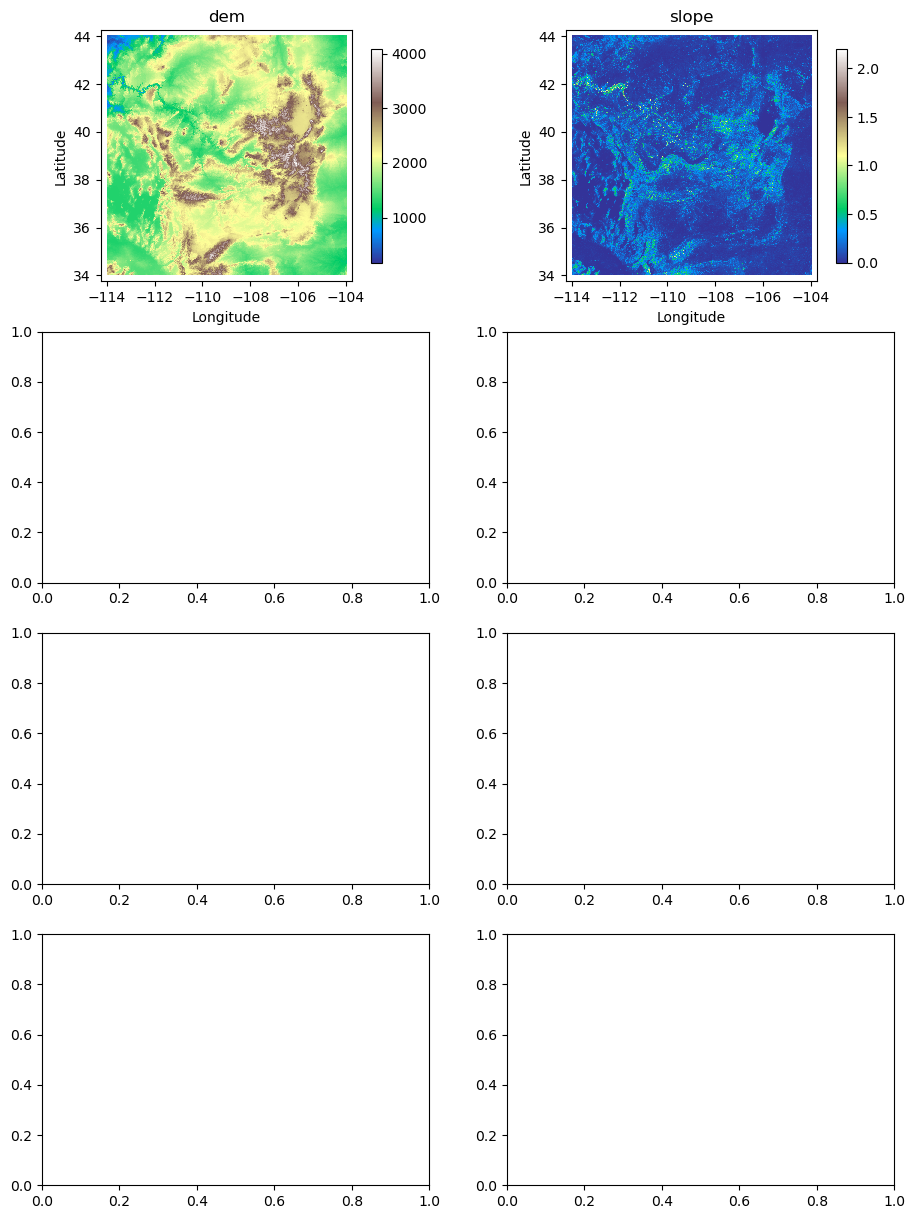

In [1]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# PATHS

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# READ HRU AND CID MAPS

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file)
cids = gdal_tools.read_raster(cids_file)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# VARIABLES
var2plot = ["dem", "slope","y_aspect", "x_aspect","svf", "tvf","hor_n", "hor_w"]
#var2plot = ["dem"]

cid_list = range(1, 1601)

# PLOT
# 

fig, axes = plt.subplots(4, 2, figsize=(11, 15))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"\nPlotting {var}", flush=True)

    final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

    for cid in cid_list:

        if cid % 50 == 0:
            print(f"  Processing CID {cid}", flush=True)

        fp_path = path + f"{cid}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}", flush=True)
            continue

        fp = nc.Dataset(fp_path)
        grp = fp.groups["parameters"]

        if var not in grp.variables:
            print(f"{var} missing in CID {cid}", flush=True)
            fp.close()
            continue

        data = np.array(grp.variables[var][:], dtype=np.float32)
        fp.close()

        mask = (hrus != -9999) & (cids == cid)

        hru_ids = hrus[mask]
        valid = (hru_ids >= 0) & (hru_ids < len(data))

        rows, cols = np.where(mask)
        final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

    final_map[final_map == -9999.0] = np.nan

    im = ax.imshow(
        final_map,
        origin="upper",
        extent=extent,
        cmap="terrain",
        interpolation="nearest"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()

outfile = os.path.join(outputdir, "static_variables_HRU_mapped_100hru_full_domain.png")
plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Processing CID 50
Processing CID 100
Processing CID 150
Processing CID 200
Processing CID 250
Processing CID 300
Processing CID 350
Processing CID 400
Processing CID 450
Processing CID 500
Processing CID 550
Processing CID 600
Processing CID 650
Processing CID 700
Processing CID 750
Processing CID 800
Processing CID 850
Processing CID 900
Processing CID 950
Processing CID 1000
Processing CID 1050
Processing CID 1100
Processing CID 1150
Processing CID 1200
Processing CID 1250
Processing CID 1300
Processing CID 1350
Processing CID 1400
Processing CID 1450
Processing CID 1500
Processing CID 1550
Processing CID 1600
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/dem_HRU_mapped_100hru_full_domain.png


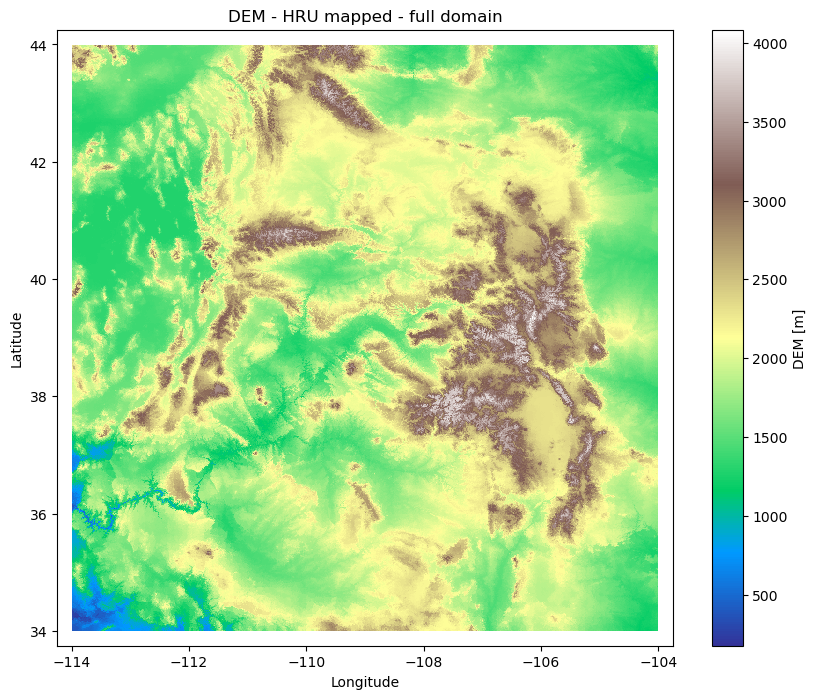

In [2]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# PATHS

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# READ HRU AND CID MAPS

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file)
cids = gdal_tools.read_raster(cids_file)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# VARIABLE TO PLOT

var = "dem"
cid_list = range(1, 1601)

# MAP HRU VALUES TO RASTER

final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

for cid in cid_list:

    if cid % 50 == 0:
        print(f"Processing CID {cid}", flush=True)

    fp_path = path + f"{cid}/input_file.nc"

    if not os.path.exists(fp_path):
        print(f"Missing: {fp_path}", flush=True)
        continue

    fp = nc.Dataset(fp_path)
    grp = fp.groups["parameters"]

    if var not in grp.variables:
        print(f"{var} missing in CID {cid}", flush=True)
        fp.close()
        continue

    data = np.array(grp.variables[var][:], dtype=np.float32)
    fp.close()

    mask = (hrus != -9999) & (cids == cid)

    hru_ids = hrus[mask]
    valid = (hru_ids >= 0) & (hru_ids < len(data))

    rows, cols = np.where(mask)
    final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

final_map[final_map == -9999.0] = np.nan

# 
# PLOT

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    final_map,
    origin="upper",
    extent=extent,
    cmap="terrain",
    interpolation="nearest"
)

ax.set_title("DEM - HRU mapped - full domain")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label="DEM [m]")

outfile = os.path.join(outputdir, "dem_HRU_mapped_100hru_full_domain.png")
plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

In [4]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools


# PATHS

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# READ HRU AND CID MAPS

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file)
cids = gdal_tools.read_raster(cids_file)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# VARIABLES
var2plot = ["dem", "slope","y_aspect", "x_aspect","svf", "tvf","hor_n", "hor_w"]
#var2plot = ["dem"]

cid_list = range(1, 1601)

# PLOT
# 

fig, axes = plt.subplots(4, 2, figsize=(11, 15))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"\nPlotting {var}", flush=True)

    final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

    for cid in cid_list:

        if cid % 50 == 0:
            print(f"  Processing CID {cid}", flush=True)

        fp_path = path + f"{cid}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}", flush=True)
            continue

        fp = nc.Dataset(fp_path)
        grp = fp.groups["parameters"]

        if var not in grp.variables:
            print(f"{var} missing in CID {cid}", flush=True)
            fp.close()
            continue

        data = np.array(grp.variables[var][:], dtype=np.float32)
        fp.close()

        mask = (hrus != -9999) & (cids == cid)

        hru_ids = hrus[mask]
        valid = (hru_ids >= 0) & (hru_ids < len(data))

        rows, cols = np.where(mask)
        final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

    final_map[final_map == -9999.0] = np.nan

    im = ax.imshow(
        final_map,
        origin="upper",
        extent=extent,
        cmap="terrain",
        interpolation="nearest"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()

outfile = os.path.join(outputdir, "static_variables_HRU_mapped_100hru_full_domain.png")
plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/


In [2]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# PATHS

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# READ HRU AND CID MAPS

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# SETTINGS

var = "smc"
season_name = "Winter"
season_months = (12, 1, 2)
cid_list = range(1, 1601)

# READ TIME FROM CID 1 MODEL OUTPUT

time_file = path + "output_data/1/2014-01-01.nc"
fp = nc.Dataset(time_file)

time = fp.groups["metadata"].variables["time"][:]

fp.close()

datetime_series = start + pd.to_timedelta(time, unit="h")
times = pd.Series(datetime_series, name="datetime")

season_index = ((times.dt.year == 2014) &(times.dt.month.isin(season_months))).values
# season_index = times.dt.month.isin(season_months).values      #All years

print("Total timesteps:", len(times))
print(f"{season_name} timesteps:", season_index.sum())

# MAP SMC VALUES TO RASTER

final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

for cid in cid_list:

    if cid % 50 == 0:
        print(f"Processing CID {cid}", flush=True)

    fp_path = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        print(f"Missing: {fp_path}", flush=True)
        continue

    fp = nc.Dataset(fp_path)
    grp = fp.groups["data"]

    if var not in grp.variables:
        print(f"{var} missing in CID {cid}", flush=True)
        fp.close()
        continue

    # smc(time, hru, soil)
    smc = np.array(grp.variables[var][:, :, 0], dtype=np.float32)
    fp.close()

    smc[smc <= -9990] = np.nan

    # seasonal mean by HRU
    data = np.nanmean(smc[season_index, :], axis=0)

    # Debug (only for the first CID)
    if cid == 1:
        print("season_index sum:", season_index.sum())
        print("smc shape:", smc.shape)
        print("selected shape:", smc[season_index, :].shape)
        print("data min:", np.nanmin(data))
        print("data max:", np.nanmax(data))


    mask = (hrus != -9999) & (cids == cid)

    hru_ids = hrus[mask].astype(np.int32)
    valid = (hru_ids >= 0) & (hru_ids < len(data))

    rows, cols = np.where(mask)
    final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

final_map[final_map == -9999.0] = np.nan

# PLOT

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    final_map,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

ax.set_title(f"SMC top layer - {season_name}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label="SMC [m³/m³]")

outfile = os.path.join(outputdir, f"smc_top_layer_{season_name}_100hru_full_domain1.png")
plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/


NameError: name 'start' is not defined

In [6]:
import netCDF4 as nc
import pandas as pd

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

for c in [1, 800, 1600]:

    print("\n" + "="*60)
    print("CID:", c)

    fp = nc.Dataset(path + f"{c}/input_file.nc")

    print("Group keys:", fp.groups.keys())

    time = fp.groups["meteorology"].variables["time"][:]

    print("time shape:", time.shape)
    print("first 10 time values:", time[:10])
    print("last 10 time values:", time[-10:])

    fp.close()

    start = pd.Timestamp("2014-01-01 00:00")
    datetime_series = start + pd.to_timedelta(time, unit="h")

    # optional local time conversion
    datetime_series_local = (
        datetime_series
        .tz_localize("UTC")
        .tz_convert("America/Denver")
    )

    times = pd.Series(datetime_series_local, name="datetime")

    print("first 5 dates:")
    print(times.head())

    print("last 5 dates:")
    print(times.tail())

    print("year range:", times.dt.year.min(), times.dt.year.max())
    print("months:", sorted(times.dt.month.unique()))


CID: 1
Group keys: dict_keys(['meteorology', 'water_use', 'metadata', 'wmatrix_Basin1', 'wmatrix_Basin2', 'wmatrix_Basin3', 'wmatrix_Basin4', 'wmatrix_Basin5', 'parameters', 'stream_network'])
time shape: (32120,)
first 10 time values: [ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27.]
last 10 time values: [96330. 96333. 96336. 96339. 96342. 96345. 96348. 96351. 96354. 96357.]
first 5 dates:
0   2013-12-31 17:00:00-07:00
1   2013-12-31 20:00:00-07:00
2   2013-12-31 23:00:00-07:00
3   2014-01-01 02:00:00-07:00
4   2014-01-01 05:00:00-07:00
Name: datetime, dtype: datetime64[ns, America/Denver]
last 5 dates:
32115   2024-12-28 02:00:00-07:00
32116   2024-12-28 05:00:00-07:00
32117   2024-12-28 08:00:00-07:00
32118   2024-12-28 11:00:00-07:00
32119   2024-12-28 14:00:00-07:00
Name: datetime, dtype: datetime64[ns, America/Denver]
year range: 2013 2024
months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

CID: 800
Group keys: dict_keys(['meteorology', 'water_use', 'metadata', 'wmatrix_Basin1', 'wmatrix_B

In [7]:
fp = nc.Dataset(path + "1/input_file.nc")

time = fp.groups["meteorology"].variables["time"][:]

fp.close()

start = pd.Timestamp("2014-01-01 00:00")

times = pd.Series(
    start + pd.to_timedelta(time, unit="h"),
    name="datetime"
)

print(times.head())
print(times.tail())

0   2014-01-01 00:00:00
1   2014-01-01 03:00:00
2   2014-01-01 06:00:00
3   2014-01-01 09:00:00
4   2014-01-01 12:00:00
Name: datetime, dtype: datetime64[ns]
32115   2024-12-28 09:00:00
32116   2024-12-28 12:00:00
32117   2024-12-28 15:00:00
32118   2024-12-28 18:00:00
32119   2024-12-28 21:00:00
Name: datetime, dtype: datetime64[ns]


Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Total timesteps: 32120
First time: 2014-01-01 00:00:00
Last time : 2024-12-28 21:00:00
Winter timesteps: 720
season_index sum: 720
smc shape: (32120, 100)
selected shape: (720, 100)
data min: 0.120418295
data max: 0.19870335
Processing CID 50
Processing CID 100
Processing CID 150
Processing CID 200
Processing CID 250
Processing CID 300
Processing CID 350
Processing CID 400
Processing CID 450
Processing CID 500
Processing CID 550
Processing CID 600
Processing CID 650
Processing CID 700
Processing CID 750
Processing CID 800
Processing CID 850
Processing CID 900
Processing CID 950
Processing CID 1000
Processing CID 1050
Processing CID 1100
Processing CID 1150
Processing CID 1200
Processing CID 1250
Processing CID 1300
Processing CID 1350
Processing CID 1400
Processing CID 1450
Processing CID 1500
Processing CID 1550
Proc

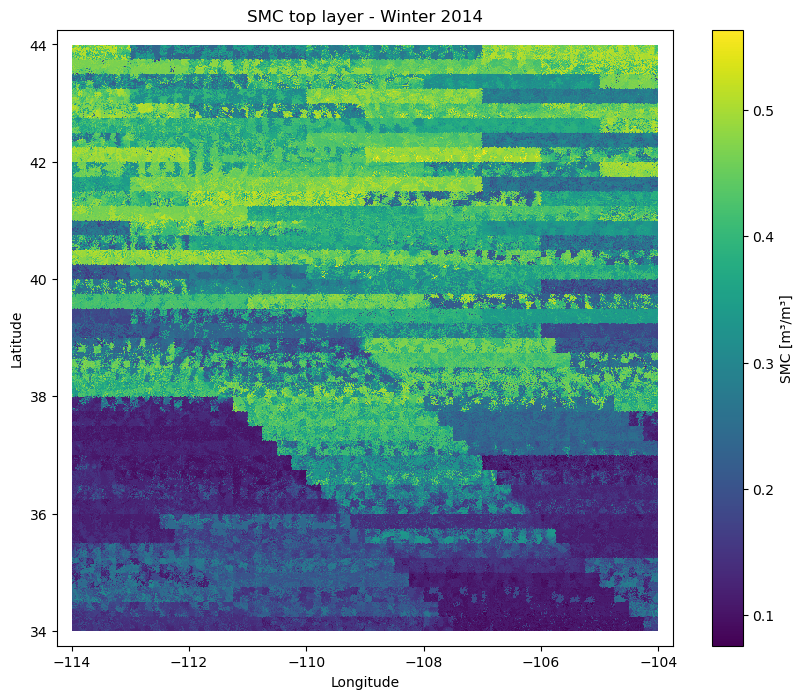

In [8]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# PATHS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# ============================================================
# READ HRU AND CID MAPS
# ============================================================

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# ============================================================
# SETTINGS
# ============================================================

var = "smc"
season_name = "Winter"
season_months = (12, 1, 2)
cid_list = range(1, 1601)

# ============================================================
# READ TIME FROM INPUT FILE
# ============================================================

time_file = path + "1/input_file.nc"

fp = nc.Dataset(time_file)
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00:00")

times = pd.Series(
    start + pd.to_timedelta(time, unit="h"),
    name="datetime"
)

season_index = (
    (times.dt.year == 2014) &
    (times.dt.month.isin(season_months))
).values

print("Total timesteps:", len(times))
print("First time:", times.iloc[0])
print("Last time :", times.iloc[-1])
print(f"{season_name} timesteps:", season_index.sum())

# ============================================================
# MAP SMC VALUES TO RASTER
# ============================================================

final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

for cid in cid_list:

    if cid % 50 == 0:
        print(f"Processing CID {cid}", flush=True)

    fp_path = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        print(f"Missing: {fp_path}", flush=True)
        continue

    fp = nc.Dataset(fp_path)
    grp = fp.groups["data"]

    if var not in grp.variables:
        print(f"{var} missing in CID {cid}", flush=True)
        fp.close()
        continue

    # smc(time, hru, soil)
    smc = np.array(grp.variables[var][:, :, 0], dtype=np.float32)
    fp.close()

    smc[smc <= -9990] = np.nan

    # seasonal mean by HRU
    data = np.nanmean(smc[season_index, :], axis=0)

    if cid == 1:
        print("season_index sum:", season_index.sum())
        print("smc shape:", smc.shape)
        print("selected shape:", smc[season_index, :].shape)
        print("data min:", np.nanmin(data))
        print("data max:", np.nanmax(data))

    mask = (hrus != -9999) & (cids == cid)

    hru_ids = hrus[mask].astype(np.int32)
    valid = (hru_ids >= 0) & (hru_ids < len(data))

    rows, cols = np.where(mask)
    final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

final_map[final_map == -9999.0] = np.nan

print("Final valid pixels:", np.sum(np.isfinite(final_map)))
print("Final min:", np.nanmin(final_map))
print("Final max:", np.nanmax(final_map))

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    final_map,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

ax.set_title(f"SMC top layer - {season_name} 2014")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label="SMC [m³/m³]")

outfile = os.path.join(
    outputdir,
    f"smc_top_layer_{season_name}_2014_100hru_full_domain.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

In [2]:
import os
import gc
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# PATHS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# ============================================================
# READ HRU AND CID MAPS ONCE
# ============================================================

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)

metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [
    metad["minx"],
    metad["maxx"],
    metad["miny"],
    metad["maxy"]
]

valid_domain = (hrus != -9999)

cid_list = range(1, 1601)

print("HRU map shape:", hrus.shape, flush=True)
print("CID map shape:", cids.shape, flush=True)

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
HRU map shape: (12601, 12601)
CID map shape: (12601, 12601)


In [3]:
# ============================================================
# VARIABLES TO MAP
# ============================================================

var2plot = [
    "dem", "slope", "y_aspect", "x_aspect",
    "svf", "tvf", "hor_n", "hor_w"
]

# This dictionary will store the final mapped raster for each variable
mapped_vars = {}

for var in var2plot:

    print(f"\nMapping variable: {var}", flush=True)

    final_map = np.full(hrus.shape, np.nan, dtype=np.float32)

    for cid in cid_list:

        if cid % 50 == 0:
            print(f"  Processing CID {cid}", flush=True)

        fp_path = path + f"{cid}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"  Missing: {fp_path}", flush=True)
            continue

        with nc.Dataset(fp_path) as fp:
            grp = fp.groups["parameters"]

            if var not in grp.variables:
                print(f"  {var} missing in CID {cid}", flush=True)
                continue

            data = np.array(grp.variables[var][:], dtype=np.float32)

        mask = valid_domain & (cids == cid)

        if not np.any(mask):
            continue

        hru_ids = hrus[mask].astype(np.int32)

        valid = (hru_ids >= 0) & (hru_ids < len(data))

        rows, cols = np.where(mask)

        final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

    mapped_vars[var] = final_map

    print(f"Finished {var}", flush=True)

    del final_map
    gc.collect()

print("\nAll variables mapped.", flush=True)
print("Variables stored:", list(mapped_vars.keys()), flush=True)


Mapping variable: dem
  Processing CID 50
  Processing CID 100
  Processing CID 150
  Processing CID 200
  Processing CID 250
  Processing CID 300
  Processing CID 350
  Processing CID 400
  Processing CID 450
  Processing CID 500
  Processing CID 550
  Processing CID 600
  Processing CID 650
  Processing CID 700
  Processing CID 750
  Processing CID 800
  Processing CID 850
  Processing CID 900
  Processing CID 950
  Processing CID 1000
  Processing CID 1050
  Processing CID 1100
  Processing CID 1150
  Processing CID 1200
  Processing CID 1250
  Processing CID 1300
  Processing CID 1350
  Processing CID 1400
  Processing CID 1450
  Processing CID 1500
  Processing CID 1550
  Processing CID 1600
Finished dem

Mapping variable: slope
  Processing CID 50
  Processing CID 100
  Processing CID 150
  Processing CID 200
  Processing CID 250
  Processing CID 300
  Processing CID 350
  Processing CID 400
  Processing CID 450
  Processing CID 500
  Processing CID 550
  Processing CID 600
  Pr

In [ ]:
# ============================================================
# PLOT 2 x 4
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for j, var in enumerate(var2plot):

    ax = axes[j]

    im = ax.imshow(
        mapped_vars[var],
        origin="upper",
        extent=extent,
        cmap="terrain",
        interpolation="nearest"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    fig.colorbar(im, ax=ax, shrink=0.75)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "static_variables_HRU_mapped_100hru_full_domain_2x4.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

In [4]:
import glob
import os
from geospatialtools import gdal_tools
import numpy as np

data_dir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids"

min_relief = []
cid_dirs = glob.glob(f"{data_dir}/*/")
print(f"Found {len(cid_dirs)} cid directories")

for cid_dir in cid_dirs:
    dem_file = os.path.join(cid_dir, "dem_latlon.tif")
    if not os.path.isfile(dem_file):
        continue
    try:
        dem = gdal_tools.read_data(dem_file).data
        valid = dem[dem != -9999]
        if valid.size == 0:
            continue
        relief = np.max(valid) - np.min(valid)
        min_relief.append((cid_dir, relief))
    except Exception as e:
        print(f"Error on {dem_file}: {e}")

min_relief.sort(key=lambda x: x[1])
print(f"\nProcessed {len(min_relief)} cids")
print("\nSmallest-relief cids:")
for f, r in min_relief[:15]:
    print(f"{f}: {r:.1f} m relief")

Found 1600 cid directories

Processed 1600 cids

Smallest-relief cids:
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1039/: 307.7 m relief
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1263/: 328.8 m relief
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1264/: 328.8 m relief
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1040/: 333.8 m relief
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1038/: 338.1 m relief
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1224/: 353.2 m relief
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/40/: 354.9 m relief
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1257/: 359.9 m relief
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1555/: 361.1 m relief
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_co